# 05 — k-mer TF-IDF Baseline

**Goal**: Treat each peptide sequence as a "document" of k-mers (subsequences of length k), and apply TF-IDF (Term Frequency-Inverse Document Frequency) vectorization. This approach often dominates on peptide datasets.

**Verify gates**:
- Tokenize sequences into k-mers (k=3 or 4)
- Fit `TfidfVectorizer` and check vocabulary size
- Train Logistic Regression and Linear SVM using **Cluster-Stratified CV**
- Compare AUC-ROC to Phase 3/4 baseline

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, roc_curve, auc

plt.style.use('dark_background')
sns.set_palette('viridis')
print('Libraries loaded ✓')

import scipy.sparse as sp

Libraries loaded ✓


## Step 5.1 & 5.2 — Tokenize & Apply TF-IDF

In [4]:
train_df = pd.read_csv('../data/processed/train_clusters.csv')
test_df  = pd.read_csv('../data/processed/test_clean.csv')

y_train = train_df['Label'].values
cluster_labels = train_df['Cluster'].values

def get_kmers(seq, k=3):
    """Convert ABCDE into 'ABC BCD CDE'"""
    return ' '.join([seq[i:i+k] for i in range(len(seq) - k + 1)])

# Apply k=3
train_kmer_texts = train_df['Sequence'].apply(lambda x: get_kmers(x, k=3))
test_kmer_texts  = test_df['Sequence'].apply(lambda x: get_kmers(x, k=3))

print('Sample tokenized sequence:')
print(train_df['Sequence'].iloc[0])
print(train_kmer_texts.iloc[0])

# Fit TF-IDF
tfidf = TfidfVectorizer(
    lowercase=False,
    analyzer='word',
    ngram_range=(1, 2),  # Use single k-mers and pairs of adjacent k-mers
    max_features=20000,
    min_df=3             # Ignore k-mers appearing in fewer than 3 sequences
)

print('\nFitting TF-IDF...')
X_train_tfidf = tfidf.fit_transform(train_kmer_texts)
X_test_tfidf  = tfidf.transform(test_kmer_texts)

print(f'TF-IDF Train shape: {X_train_tfidf.shape}')
print(f'TF-IDF Test shape:  {X_test_tfidf.shape}')

Sample tokenized sequence:
AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS
AAA AAA AAA AAA AAA AAA AAA AAA AAG AGI GIG IGK GKF KFL FLH LHS HSA SAK AKK KKF KFG FGK GKA KAF AFV FVG VGE GEI EIM IMN MNS

Fitting TF-IDF...
TF-IDF Train shape: (7143, 19856)
TF-IDF Test shape:  (1917, 19856)


## Step 5.3 & 5.4 — Train Logistic Regression & Linear SVM
Using **Cluster CV** (which gave AUC ~0.741 for the dense features).

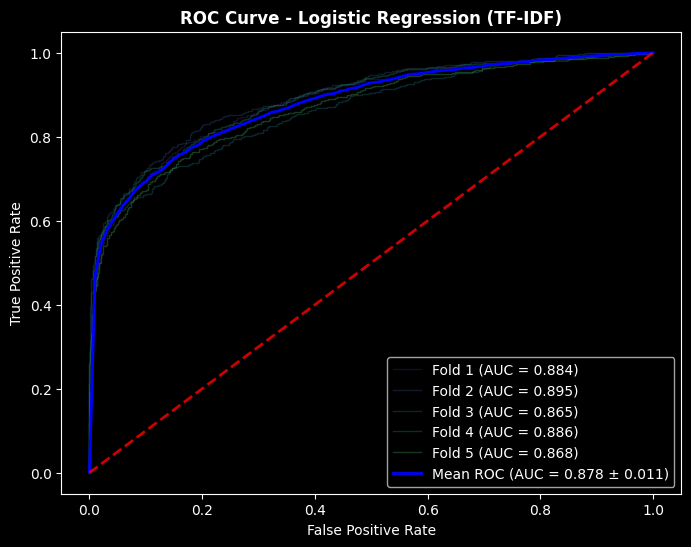

Logistic Regression Cluster CV: Mean AUC = 0.8782 ± 0.0114


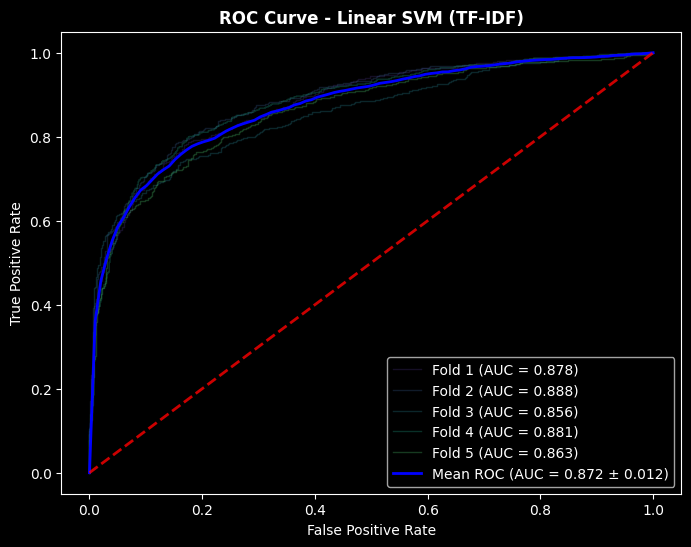

Linear SVM Cluster CV: Mean AUC = 0.8723 ± 0.0119


In [5]:
def evaluate_sparse_cv(model_name, model_fn):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    
    oof_preds = np.zeros(X_train_tfidf.shape[0])
    fold_metrics = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_tfidf, y_train, groups=cluster_labels)):
        X_tr, y_tr = X_train_tfidf[train_idx], y_train[train_idx]
        X_va, y_va = X_train_tfidf[val_idx], y_train[val_idx]
        
        model = model_fn()
        model.fit(X_tr, y_tr)
        
        preds = model.predict_proba(X_va)[:, 1] 
        oof_preds[val_idx] = preds
        
        auc_score = roc_auc_score(y_va, preds)
        fold_metrics.append(auc_score)
        
        fpr, tpr, _ = roc_curve(y_va, preds)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        
        ax.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {fold+1} (AUC = {auc_score:.3f})')

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(fold_metrics)
    
    ax.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})', lw=2)
    ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=0.8)
    
    ax.set_title(f'ROC Curve - {model_name} (TF-IDF)', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right")
    plt.show()
    
    print(f"{model_name} Cluster CV: Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}")
    return mean_auc, oof_preds

# 1. Logistic Regression
lr_fn = lambda: LogisticRegression(max_iter=1000, random_state=42, C=1.0, n_jobs=-1)
lr_auc, oof_lr = evaluate_sparse_cv("Logistic Regression", lr_fn)

# 2. Linear SVM with Platt Scaling (Calibrated Classifier CV wraps the hinge loss)
# SVM hinge loss defaults don't give probabilities, CalibratedClassifierCV adds them
svm_fn = lambda: CalibratedClassifierCV(
    estimator=SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, random_state=42, n_jobs=-1, max_iter=1000),
    method='sigmoid',
    cv=3
)
svm_auc, oof_svm = evaluate_sparse_cv("Linear SVM", svm_fn)

## Step 5.5 — Save TF-IDF Out-of-Fold Predictions
These are valuable for the final ensemble step.

In [6]:
oof_df = pd.DataFrame({
    'Sequence': train_df['Sequence'],
    'Label': y_train,
    'tfidf_lr_pred': oof_lr,
    'tfidf_svm_pred': oof_svm
})
oof_df.to_csv('../data/processed/oof_tfidf.csv', index=False)
print('Saved text TF-IDF out-of-fold predictions to data/processed/oof_tfidf.csv')

# Write out Sparse features for test evaluation later
sp.save_npz('../data/processed/X_train_tfidf.npz', X_train_tfidf)
sp.save_npz('../data/processed/X_test_tfidf.npz',  X_test_tfidf)
print('Saved sparse TF-IDF feature matrices (.npz)')

Saved text TF-IDF out-of-fold predictions to data/processed/oof_tfidf.csv
Saved sparse TF-IDF feature matrices (.npz)
